---
title: "Planets"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Exoplanets
- **description:** 1,035 confirmed exoplanets — planets outside our solar system — discovered through 2014, with orbital and discovery attributes.
- **provenance:** NASA Exoplanet Archive.
- **format:** long / tidy — 1,035 rows x 6 columns.

**Data dictionary**

- `method` — *(identifier)* discovery technique (e.g., Radial Velocity, Transit; 10 methods total).
- `number` — *(measurement)* number of planets in that planetary system.
- `orbital_period` — *(measurement)* time for one orbit, in days.
- `mass` — *(measurement)* planet mass, in Jupiter masses.
- `distance` — *(measurement)* distance from Earth, in parsecs.
- `year` — *(identifier)* year of discovery (1989–2014).

**Structure**

- **Rows:** 1,035 — one row per exoplanet.
- **Columns:** 6.
- **Identifiers:** `method`, `year`.
- **Measurements:** `number`, `orbital_period`, `mass`, `distance`.

**Use cases**

- how discovery methods (e.g., the transit method) evolved over time
- comparing masses and distances by discovery method
- counts of discoveries by method and year


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

## Long form (tidy)

In [2]:
planets = sns.load_dataset('planets')
planets.info()
planets

<class 'pandas.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   str    
 1   number          1035 non-null   int64  
 2   orbital_period  992 non-null    float64
 3   mass            513 non-null    float64
 4   distance        808 non-null    float64
 5   year            1035 non-null   int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 48.6 KB


,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008


## Wide form 1 by 1

In [33]:
planets1 = planets.value_counts(['year','method']).unstack(fill_value=0).sort_index()
planets1

method,Radial Velocity,Imaging,Eclipse Timing Variations,Transit,Astrometry,Transit Timing Variations,Orbital Brightness Modulation,Microlensing,Pulsar Timing,Pulsation Timing Variations
year,,,,,,,,,,
1989,1,0,0,0,0,0,0,0,0,0
1992,0,0,0,0,0,0,0,0,2,0
1994,0,0,0,0,0,0,0,0,1,0
1995,1,0,0,0,0,0,0,0,0,0
1996,6,0,0,0,0,0,0,0,0,0
1997,1,0,0,0,0,0,0,0,0,0
1998,5,0,0,0,0,0,0,0,0,0
1999,15,0,0,0,0,0,0,0,0,0
2000,16,0,0,0,0,0,0,0,0,0


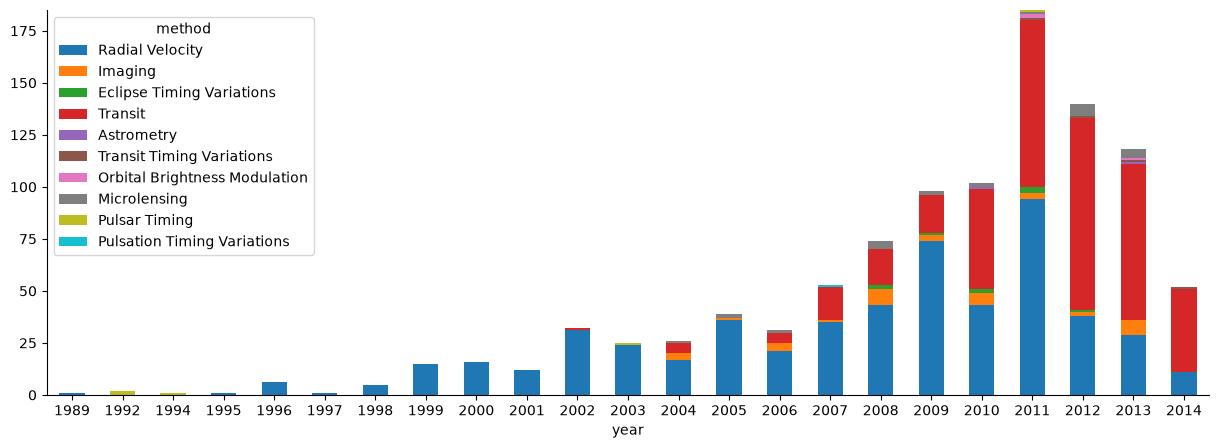

In [28]:
planets1.plot.bar(figsize=(15,5), stacked=True, rot=0)
sns.despine()
plt.show()

## Long form with pseudo key index

In [30]:
planets2 = planets.sort_values(['year','method']).copy()
planets2['year_inst'] = planets2.groupby(['year','method']).cumcount() + 1
planets2 = planets2.set_index(['year','method','year_inst']).sort_index()
planets2

number  orbital_period    mass  \
year method                    year_inst                                   
1989 Radial Velocity           1               1       83.888000  11.680   
1992 Pulsar Timing             1               3       25.262000     NaN   
                               2               3       66.541900     NaN   
1994 Pulsar Timing             1               3       98.211400     NaN   
1995 Radial Velocity           1               1        4.230785   0.472   
...                                          ...             ...     ...   
2014 Transit                   37              1       68.958400     NaN   
                               38              1        1.720861     NaN   
                               39              1       66.262000     NaN   
                               40              1        0.925542     NaN   
     Transit Timing Variations 1               3             NaN     NaN   

                                          distance  
year method                    year_inst            
1989 Radial Velocity           1             40.57  
1992 Pulsar Timing             1               NaN  
                               2               NaN  
1994 Pulsar Timing             1               NaN  
1995 Radial Velocity           1             15.36  
...                                            ...  
2014 Transit                   37              NaN  
                               38          1056.00  
                               39              NaN  
                               40           470.00  
     Transit Timing Variations 1               NaN  

[1035 rows x 4 columns]

## Long form aggregate 

In [71]:
planets3 = planets.groupby('method').agg(
    mass_mean = ('mass','mean'),
    distance_mean = ('distance','mean'), 
    number_sum = ('number','sum'), 
    count = ('number', 'count'),
    year_start = ('year', 'min')).sort_values('year_start').fillna(0)

In [72]:
planets3

,mass_mean,distance_mean,number_sum,count,year_start
method,,,,,
Radial Velocity,2.630699,51.600208,952,553,1989
Pulsar Timing,0.000000,1200.000000,11,5,1992
Transit,1.470000,599.298080,776,397,2002
Imaging,0.000000,67.715937,50,38,2004
Microlensing,0.000000,4144.000000,27,23,2004
Pulsation Timing Variations,0.000000,0.000000,1,1,2007
Eclipse Timing Variations,5.125000,315.360000,15,9,2008
Astrometry,0.000000,17.875000,2,2,2010
Orbital Brightness Modulation,0.000000,1180.000000,5,3,2011


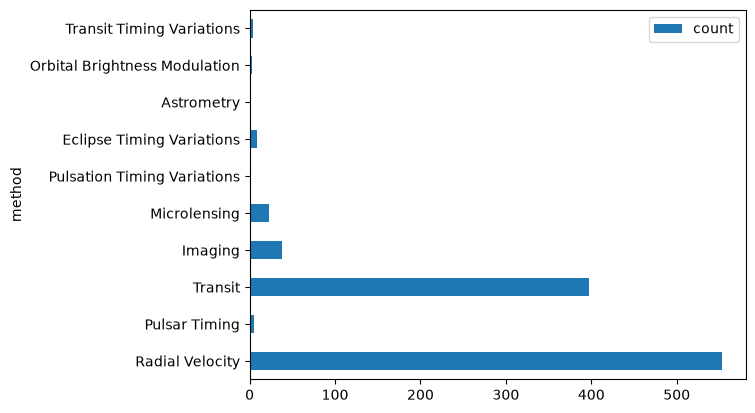

In [77]:
planets3.plot.barh(y=['count'])
plt.show()